In [1]:
import pandas as pd

# Load BTC CSV
btc_df = pd.read_csv(r'feature_datasets\BTC_features.csv', parse_dates=True, index_col=0)

# Define X and y
btc_y = btc_df['Close'].shift(-1)          # next-day close price
btc_X = btc_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
btc_X = btc_X.iloc[:-1]
btc_y = btc_y.iloc[:-1]

# Optional: check shapes
print("BTC X shape:", btc_X.shape)
print("BTC y shape:", btc_y.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


## Basic 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(btc_X) * 0.7)

btc_X_train = btc_X.iloc[:split_idx].values
btc_X_test  = btc_X.iloc[split_idx:].values

btc_y_train = btc_y.iloc[:split_idx].values
btc_y_test  = btc_y.iloc[split_idx:].values

# Optional: check shapes
print("BTC X_train shape:", btc_X_train.shape)
print("BTC X_test shape:", btc_X_test.shape)
print("BTC y_train shape:", btc_y_train.shape)
print("BTC y_test shape:", btc_y_test.shape)

BTC X_train shape: (640, 29)
BTC X_test shape: (275, 29)
BTC y_train shape: (640,)
BTC y_test shape: (275,)


In [5]:
! pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- -------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\tharu\anaconda3\envs\Streamlit\python.exe -m pip install --upgrade pip


In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Assuming btc_df has Date as index
# After splitting your data 70-30
btc_test_dates = btc_df.index[-len(btc_X_test):]  # get the dates for test set

In [22]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
btc_X_train_scaled = scaler.fit_transform(btc_X_train)

# Transform TEST using the same scaler
btc_X_test_scaled = scaler.transform(btc_X_test)

# Check shapes
print("Scaled X_train shape:", btc_X_train_scaled.shape)
print("Scaled X_test shape:", btc_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [23]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
btc_y_train_scaled = y_scaler.fit_transform(btc_y_train.reshape(-1,1)).flatten()

# Scale test target
btc_y_test_scaled = y_scaler.transform(btc_y_test.reshape(-1,1)).flatten()

In [24]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BTC using scaled target
btc_X_train_seq, btc_y_train_seq = create_sequences(btc_X_train_scaled, btc_y_train_scaled, time_steps=30)
btc_X_test_seq, btc_y_test_seq = create_sequences(btc_X_test_scaled, btc_y_test_scaled, time_steps=30)

# Check shapes
print("BTC X_train_seq shape:", btc_X_train_seq.shape)
print("BTC y_train_seq shape:", btc_y_train_seq.shape)
print("BTC X_test_seq shape:", btc_X_test_seq.shape)
print("BTC y_test_seq shape:", btc_y_test_seq.shape)

BTC X_train_seq shape: (610, 30, 29)
BTC y_train_seq shape: (610,)
BTC X_test_seq shape: (245, 30, 29)
BTC y_test_seq shape: (245,)


## Training the model for the basic split

In [25]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [26]:
# Get number of features from the sequences
input_size = btc_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [27]:
model = train_model(
    model,
    btc_X_train_seq,
    btc_y_train_seq,
    epochs=50,       # you can adjust later
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.002062
Epoch [20/50], Loss: 0.002329
Epoch [30/50], Loss: 0.001333
Epoch [40/50], Loss: 0.001314
Epoch [50/50], Loss: 0.002069


In [28]:
btc_preds = predict_model(model, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds.shape)
print("First 10 predictions:", btc_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.25494456]
 [0.24400413]
 [0.23829027]
 [0.23217843]
 [0.22841425]
 [0.22491498]
 [0.22363122]
 [0.2194701 ]
 [0.20952131]
 [0.20628914]]


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")


MSE: 5762051.39
RMSE: 2400.43
MAE: 1699.34
R2 Score: 0.8130


In [29]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = btc_df.index[-len(btc_X_test):][30:]  # test dates aligned with sequences
actual_seq = btc_y_test[30:]                      # actual prices aligned
pred_seq = btc_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,28680.537109,28988.195312
2023-05-03,29006.308594,28421.705078
2023-05-04,28847.710938,28125.845703
2023-05-05,29534.384766,27809.376953
2023-05-06,28904.623047,27614.470703
...,...,...
2023-12-28,42627.855469,37401.718750
2023-12-29,42099.402344,37851.859375
2023-12-30,42156.902344,38132.722656


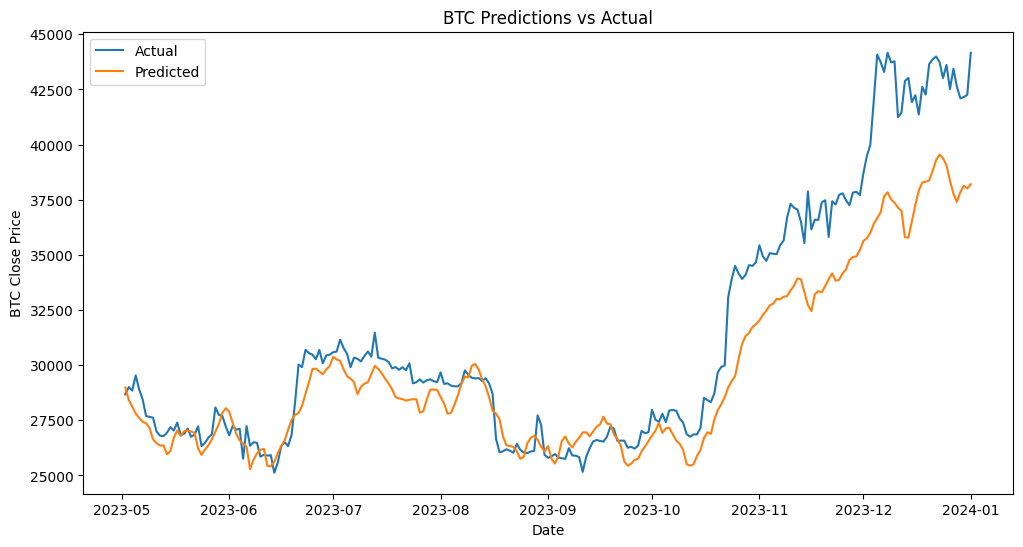

In [32]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% train split

### Preparing the train and test datasets

In [41]:
# Get unique years from your DataFrame index
years = btc_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [42]:
X_train_list = []
y_train_list = []

In [43]:
for year in years:
    # Filter data for this year
    btc_year = btc_df[btc_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(btc_year) * 0.7)

    # Take first 70% as training
    X_train_year = btc_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = btc_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [44]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [48]:
X_test_list = []
y_test_list = []

In [49]:
for year in years:
    btc_year = btc_df[btc_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(btc_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = btc_year.iloc[split_idx:, 1:].values   # features
    y_test_year = btc_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [50]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [51]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [54]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [55]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

In [56]:
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)


Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)
